[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train YOLO11 Object Detection on a Custom Dataset

---

[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/ultralytics/ultralytics)

YOLO11 builds on the advancements introduced in YOLOv9 and YOLOv10 earlier this year, incorporating improved architectural designs, enhanced feature extraction techniques, and optimized training methods.

YOLO11m achieves a higher mean mAP score on the COCO dataset while using 22% fewer parameters than YOLOv8m, making it computationally lighter without sacrificing performance.

YOLOv11 is available in 5 different sizes, ranging from `2.6M` to `56.9M` parameters, and capable of achieving from `39.5` to `54.7` mAP on the COCO dataset.

## Setup

### Configure API keys

To fine-tune YOLO11, you need to provide your Roboflow API key. Follow these steps:

- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

### Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Wed Apr 30 18:16:37 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLO11 via Ultralytics

In [3]:
%pip install "ultralytics<=8.3.40" supervision roboflow
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.4/112.6 GB disk)


## Inference with model pre-trained on COCO dataset

### CLI

**NOTE:** CLI requires no customization or Python code. You can simply run all tasks from the terminal with the yolo command.

In [4]:
!yolo task=detect mode=predict model=yolo11n.pt conf=0.25 source='https://media.roboflow.com/notebooks/examples/dog.jpeg' save=True

100% 5.35M/5.35M [00:00<00:00, 68.4MB/s]
Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

100% 104k/104k [00:00<00:00, 78.5MB/s]
image 1/1 /content/dog.jpeg: 640x384 2 persons, 1 car, 1 dog, 1 handbag, 41.4ms
Speed: 14.3ms preprocess, 41.4ms inference, 394.9ms postprocess per image at shape (1, 3, 640, 384)
Results saved to runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


**NOTE:** Result annotated image got saved in `{HOME}/runs/detect/predict/`. Let's display it.

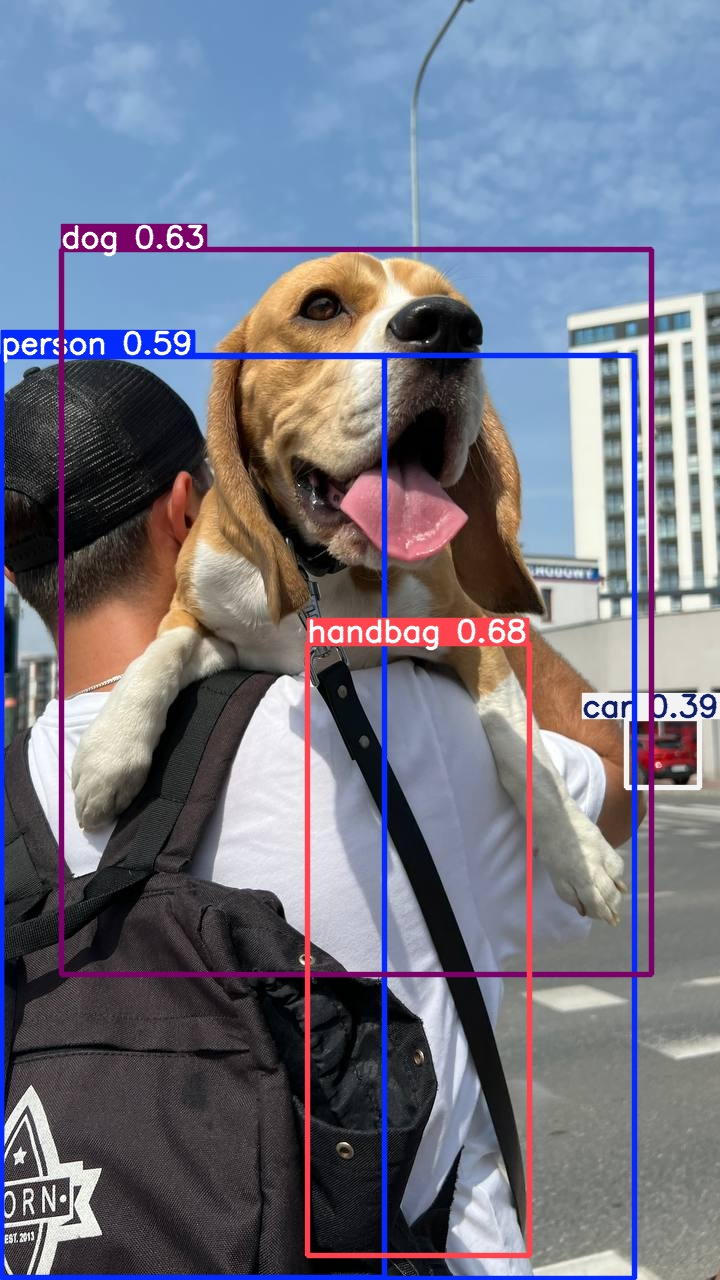

In [6]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/predict/dog.jpg', width=600)

### SDK

**NOTE:** YOLO's Python interface allows for seamless integration into your Python projects, making it easy to load, run, and process the model's output.

In [7]:
from ultralytics import YOLO
from PIL import Image
import requests

model = YOLO('yolo11n.pt')
image = Image.open(requests.get('https://media.roboflow.com/notebooks/examples/dog.jpeg', stream=True).raw)
result = model.predict(image, conf=0.25)[0]


0: 640x384 2 persons, 1 car, 1 dog, 1 handbag, 54.2ms
Speed: 3.1ms preprocess, 54.2ms inference, 143.9ms postprocess per image at shape (1, 3, 640, 384)


**NOTE:** The obtained `result` object stores information about the location, classes, and confidence levels of the detected objects.

In [8]:
result.boxes.xyxy

tensor([[3.0705e+02, 6.4341e+02, 5.2919e+02, 1.2558e+03],
        [6.1400e+01, 2.4994e+02, 6.5165e+02, 9.7412e+02],
        [1.7803e+00, 3.5551e+02, 6.3404e+02, 1.2788e+03],
        [1.1933e+00, 3.5620e+02, 3.8455e+02, 1.2776e+03],
        [6.2615e+02, 7.1818e+02, 6.9975e+02, 7.8754e+02]], device='cuda:0')

In [9]:
result.boxes.conf

tensor([0.6832, 0.6284, 0.5941, 0.3923, 0.3875], device='cuda:0')

In [10]:
result.boxes.cls

tensor([26., 16.,  0.,  0.,  2.], device='cuda:0')

**NOTE:** YOLO11 can be easily integrated with `supervision` using the familiar `from_ultralytics` connector.

In [11]:
import supervision as sv

detections = sv.Detections.from_ultralytics(result)

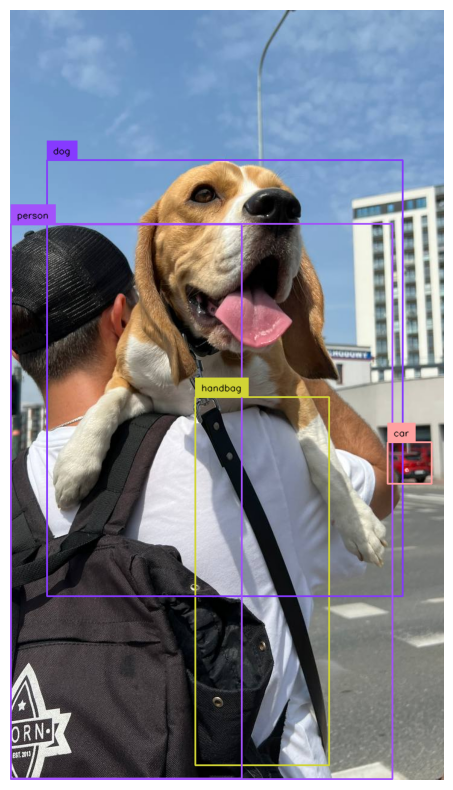

In [12]:
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK)

annotated_image = image.copy()
annotated_image = box_annotator.annotate(annotated_image, detections=detections)
annotated_image = label_annotator.annotate(annotated_image, detections=detections)

sv.plot_image(annotated_image, size=(10, 10))

## Fine-tune YOLO11 on custom dataset

**NOTE:** When training YOLOv11, make sure your data is located in `datasets`. If you'd like to change the default location of the data you want to use for fine-tuning, you can do so through Ultralytics' `settings.json`. In this tutorial, we will use one of the [datasets](https://universe.roboflow.com/liangdianzhong/-qvdww) available on [Roboflow Universe](https://universe.roboflow.com/). When downloading, make sure to select the `yolov11` export format.

In [18]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
from roboflow import Roboflow

# ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
ROBOFLOW_API_KEY = 'LUyk335leXSb5LPcrdzZ'
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

workspace = rf.workspace("joshs-data-science-projects")
project = workspace.project("food-detection-rxmdl-boyoj")
version = project.version(4)
dataset = version.download("yolov11")

mkdir: cannot create directory ‘/content/datasets’: File exists
/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Food-Detection-4 in yolov11:: 100%|██████████| 5368/5368 [00:01<00:00, 5170.42it/s]


## Balance Dataset

In [25]:
!pip install albumentations

In [28]:
import os
import cv2
import albumentations as A
import random
import shutil
from collections import defaultdict
from glob import glob

# CONFIG
BASE_DIR = "/content/datasets/Food-Detection-4"
AUG_IMAGE_DIR = os.path.join(BASE_DIR, "augmented")
FINAL_SPLIT_DIR = os.path.join(BASE_DIR, "balanced_split")
SPLIT_RATIOS = {'train': 0.7, 'val': 0.2, 'test': 0.1}
SUBSETS = ['train', 'val', 'test']
random.seed(42)

# Albumentations transform for synthetic data
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.HueSaturationValue(p=0.3),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# Step 1: Load data per class
class_to_images = defaultdict(list)

for subset in SUBSETS:
    image_dir = os.path.join(BASE_DIR, subset, 'images')
    label_dir = os.path.join(BASE_DIR, subset, 'labels')

    image_files = glob(os.path.join(image_dir, "*.jpg"))

    for img_path in image_files:
        filename = os.path.basename(img_path).replace(".jpg", "")
        label_path = os.path.join(label_dir, filename + ".txt")
        if not os.path.exists(label_path):
            continue

        with open(label_path, "r") as f:
            lines = f.readlines()
        if not lines:
            continue

        class_ids = {int(line.split()[0]) for line in lines}
        for cls in class_ids:
            class_to_images[cls].append((img_path, label_path))

print(f"Loaded data for {len(class_to_images)} classes.")

# Step 2: Augment data to balance
max_count = max(len(v) for v in class_to_images.values())
print(f"Largest class has {max_count} samples. Balancing others to match...")

os.makedirs(AUG_IMAGE_DIR, exist_ok=True)
all_data = []

for cls, samples in class_to_images.items():
    all_data.extend([(img, lbl, cls) for img, lbl in samples])

    current_count = len(samples)
    needed = max_count - current_count

    for i in range(needed):
        img_path, label_path = random.choice(samples)
        image = cv2.imread(img_path)

        with open(label_path, "r") as f:
            lines = f.readlines()

        bboxes = []
        class_labels = []

for line in lines:
    parts = line.strip().split()
    if len(parts) != 5:
        print(f"⚠️ Skipping malformed label line in {label_path}: {line.strip()}")
        continue
    try:
        class_id = int(parts[0])
        x_center, y_center, w, h = map(float, parts[1:])
        bboxes.append([x_center, y_center, w, h])
        class_labels.append(class_id)
    except ValueError:
        print(f"⚠️ Value error in {label_path}: {line.strip()}")
        continue


        try:
            augmented = transform(image=image, bboxes=bboxes, class_labels=class_labels)
        except:
            continue  # Skip if augmentation fails

        aug_img = augmented['image']
        aug_bboxes = augmented['bboxes']
        aug_labels = augmented['class_labels']

        base_name = f"class{cls}_aug_{i}_{random.randint(1000,9999)}"
        aug_img_path = os.path.join(AUG_IMAGE_DIR, base_name + ".jpg")
        aug_label_path = os.path.join(AUG_IMAGE_DIR, base_name + ".txt")

        cv2.imwrite(aug_img_path, aug_img)
        with open(aug_label_path, 'w') as f:
            for bbox, label in zip(aug_bboxes, aug_labels):
                f.write(f"{label} {' '.join(map(str, bbox))}\n")

        all_data.append((aug_img_path, aug_label_path, cls))

print("✅ Dataset balanced.")

# Step 3: Split into train, val, test (new folders)
split_dirs = {}
for split in SPLIT_RATIOS:
    split_dirs[split] = {
        'images': os.path.join(FINAL_SPLIT_DIR, split, 'images'),
        'labels': os.path.join(FINAL_SPLIT_DIR, split, 'labels')
    }
    os.makedirs(split_dirs[split]['images'], exist_ok=True)
    os.makedirs(split_dirs[split]['labels'], exist_ok=True)

# Group by class for equal splitting
split_class_data = defaultdict(list)
for img, lbl, cls in all_data:
    split_class_data[cls].append((img, lbl))

for cls, items in split_class_data.items():
    random.shuffle(items)
    n = len(items)
    n_train = int(n * SPLIT_RATIOS['train'])
    n_val = int(n * SPLIT_RATIOS['val'])

    split_data = {
        'train': items[:n_train],
        'val': items[n_train:n_train + n_val],
        'test': items[n_train + n_val:]
    }

    for split, file_pairs in split_data.items():
        for img_path, lbl_path in file_pairs:
            shutil.copy(img_path, os.path.join(split_dirs[split]['images'], os.path.basename(img_path)))
            shutil.copy(lbl_path, os.path.join(split_dirs[split]['labels'], os.path.basename(lbl_path)))

print(f"✅ Final dataset split created at: {FINAL_SPLIT_DIR}")


Loaded data for 19 classes.
Largest class has 496 samples. Balancing others to match...
✅ Dataset balanced.
✅ Final dataset split created at: /content/datasets/Food-Detection-4/balanced_split


## Summary of Count of Data per Classes

In [33]:
import os
import shutil
from collections import Counter
from glob import glob
import random

# Define paths
FINAL_SPLIT_DIR = "/content/datasets/Food-Detection-4"
AUG_IMAGE_DIR = "/content/datasets/Food-Detection-4/augmented"  # or wherever your synthetic data was saved
TRAIN_SPLIT_DIR = os.path.join(FINAL_SPLIT_DIR, "train")
VAL_SPLIT_DIR = os.path.join(FINAL_SPLIT_DIR, "val")
TEST_SPLIT_DIR = os.path.join(FINAL_SPLIT_DIR, "test")

# Optional: Class ID to Name Mapping (edit this as per your dataset)
class_id_to_name = {
    0: "Chicken",
    1: "GADC - Burger Steak",
    2: "GADC - Cheeseburger",
    3: "GADC - Cheeseburger TO",
    4: "GADC - Crispy Chicken Fillet Meal",
    5: "GADC - Crispy Chicken Fillet Meal TO",
    6: "GADC - Crispy Chicken Sandwich",
    7: "GADC - Crispy Chicken Sandwich TO",
    8: "GADC - Fries",
    9: "GADC - McNuggets",
    10: "GADC - McNuggets TO",
    11: "JFC - Burger Steak",
    12: "JFC - Burger Steak TO",
    13: "JFC - Cheesy Classic Jolly Hotdog",
    14: "JFC - Cheesy Classic Jolly Hotdog TO",
    15: "JFC - Chickenjoy TO",
    16: "JFC - Jolly Crispy Fries",
    17: "JFC - Jolly Spaghetti",
    18: "JFC - Jolly Spaghetti - Pan",
    19: "JFC - Jolly Spaghetti TO"
}

# Function to extract class IDs from label file
def extract_classes_from_label(label_path):
    with open(label_path, "r") as f:
        lines = f.readlines()

    class_ids = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 5:
            continue  # skip malformed lines
        try:
            class_id = int(float(parts[0]))  # handles both '16' and '16.0'
            class_ids.append(class_id)
        except ValueError:
            print(f"⚠️ Skipping invalid line in {label_path}: {line.strip()}")
            continue
    return class_ids

# Initialize summary structure
summary = {
    'train': Counter(),
    'val': Counter(),
    'test': Counter(),
    'augmented': Counter()
}

# Collect counts from train/val/test
for split in ['train', 'val', 'test']:
    label_dir = os.path.join(FINAL_SPLIT_DIR, split, 'labels')
    label_files = glob(os.path.join(label_dir, "*.txt"))

    for lbl_path in label_files:
        class_ids = extract_classes_from_label(lbl_path)
        for cls_id in class_ids:
            summary[split][cls_id] += 1

# Collect counts from augmented data
aug_label_files = glob(os.path.join(AUG_IMAGE_DIR, "*.txt"))
for lbl_path in aug_label_files:
    class_ids = extract_classes_from_label(lbl_path)
    for cls_id in class_ids:
        summary['augmented'][cls_id] += 1

# Determine the maximum class count across splits
max_count = max(max(summary['train'].values(), default=0), max(summary['val'].values(), default=0), max(summary['test'].values(), default=0))
print(f"Maximum count across splits: {max_count}")

# Balancing strategy: Generate synthetic data for underrepresented classes
for cls_id in range(20):  # 20 classes based on your dataset
    train_count = summary['train'].get(cls_id, 0)
    val_count = summary['val'].get(cls_id, 0)
    test_count = summary['test'].get(cls_id, 0)

    # If the class is underrepresented in train or val split, augment it
    if train_count < max_count:
        print(f"⚠️ Augmenting class {cls_id} ({class_id_to_name.get(cls_id, 'Unknown')})")
        # Here, implement the logic to create augmented data and save it to the corresponding directories
        # Example: Augment images and labels for this class and copy them to the correct folder
        pass

# Optionally, manually re-split data to ensure each class has at least some data in train/val/test
# Example: move files to correct directories, ensuring no class is left behind

# ✅ Print final summary with "Total" column
print("\n📦 FINAL DATA SUMMARY")
print(f"Total classes: {len(class_id_to_name)}\n")

header = f"{'Class ID':<9} | {'Class Name':<40} | {'Train':>5} | {'Val':>5} | {'Test':>5} | {'Augmented':>9} | {'Total':>6}"
print(header)
print("-" * len(header))

for cls in range(20):  # Adjust based on the number of classes
    name = class_id_to_name.get(cls, "Unknown")
    train = summary['train'].get(cls, 0)
    val = summary['val'].get(cls, 0)
    test = summary['test'].get(cls, 0)
    aug = summary['augmented'].get(cls, 0)
    total = train + val + test + aug
    print(f"{cls:<9} | {name:<40} | {train:>5} | {val:>5} | {test:>5} | {aug:>9} | {total:>6}")


Maximum count across splits: 500
⚠️ Augmenting class 0 (Chicken)
⚠️ Augmenting class 1 (GADC - Burger Steak)
⚠️ Augmenting class 2 (GADC - Cheeseburger)
⚠️ Augmenting class 3 (GADC - Cheeseburger TO)
⚠️ Augmenting class 4 (GADC - Crispy Chicken Fillet Meal)
⚠️ Augmenting class 5 (GADC - Crispy Chicken Fillet Meal TO)
⚠️ Augmenting class 6 (GADC - Crispy Chicken Sandwich)
⚠️ Augmenting class 7 (GADC - Crispy Chicken Sandwich TO)
⚠️ Augmenting class 9 (GADC - McNuggets)
⚠️ Augmenting class 10 (GADC - McNuggets TO)
⚠️ Augmenting class 11 (JFC - Burger Steak)
⚠️ Augmenting class 12 (JFC - Burger Steak TO)
⚠️ Augmenting class 13 (JFC - Cheesy Classic Jolly Hotdog)
⚠️ Augmenting class 14 (JFC - Cheesy Classic Jolly Hotdog TO)
⚠️ Augmenting class 15 (JFC - Chickenjoy TO)
⚠️ Augmenting class 16 (JFC - Jolly Crispy Fries)
⚠️ Augmenting class 17 (JFC - Jolly Spaghetti)
⚠️ Augmenting class 18 (JFC - Jolly Spaghetti - Pan)
⚠️ Augmenting class 19 (JFC - Jolly Spaghetti TO)

📦 FINAL DATA SUMMARY
Tot

In [32]:
import os
from glob import glob
from collections import Counter
import shutil
import random

# ✅ Update these paths as needed
FINAL_SPLIT_DIR = "/content/datasets/Food-Detection-4"
AUG_IMAGE_DIR = "/content/datasets/Food-Detection-4/augmented"  # or wherever your synthetic data was saved
TRAIN_SPLIT_DIR = os.path.join(FINAL_SPLIT_DIR, "train")
VAL_SPLIT_DIR = os.path.join(FINAL_SPLIT_DIR, "val")
TEST_SPLIT_DIR = os.path.join(FINAL_SPLIT_DIR, "test")

# Optional: class ID to name mapping (edit this based on your dataset)
class_id_to_name = {
    0: "Chicken",
    1: "GADC - Burger Steak",
    2: "GADC - Cheeseburger",
    3: "GADC - Cheeseburger TO",
    4: "GADC - Crispy Chicken Fillet Meal",
    5: "GADC - Crispy Chicken Fillet Meal TO",
    6: "GADC - Crispy Chicken Sandwich",
    7: "GADC - Crispy Chicken Sandwich TO",
    8: "GADC - Fries",
    9: "GADC - McNuggets",
    10: "GADC - McNuggets TO",
    11: "JFC - Burger Steak",
    12: "JFC - Burger Steak TO",
    13: "JFC - Cheesy Classic Jolly Hotdog",
    14: "JFC - Cheesy Classic Jolly Hotdog TO",
    15: "JFC - Chickenjoy TO",
    16: "JFC - Jolly Crispy Fries",
    17: "JFC - Jolly Spaghetti",
    18: "JFC - Jolly Spaghetti - Pan",
    19: "JFC - Jolly Spaghetti TO"
}

# Function to extract class IDs from label file
def extract_classes_from_label(label_path):
    with open(label_path, "r") as f:
        lines = f.readlines()

    class_ids = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 5:
            continue  # skip malformed lines
        try:
            class_id = int(float(parts[0]))  # handles both '16' and '16.0'
            class_ids.append(class_id)
        except ValueError:
            print(f"⚠️ Skipping invalid line in {label_path}: {line.strip()}")
            continue
    return class_ids

# Initialize summary structure
summary = {
    'train': Counter(),
    'val': Counter(),
    'test': Counter(),
    'augmented': Counter()
}

# Collect counts from train/val/test
for split in ['train', 'val', 'test']:
    label_dir = os.path.join(FINAL_SPLIT_DIR, split, 'labels')
    label_files = glob(os.path.join(label_dir, "*.txt"))

    for lbl_path in label_files:
        class_ids = extract_classes_from_label(lbl_path)
        for cls_id in class_ids:
            summary[split][cls_id] += 1

# Collect counts from augmented data
aug_label_files = glob(os.path.join(AUG_IMAGE_DIR, "*.txt"))
for lbl_path in aug_label_files:
    class_ids = extract_classes_from_label(lbl_path)
    for cls_id in class_ids:
        summary['augmented'][cls_id] += 1

# Check which classes are underrepresented and augment them if necessary
max_count = max(max(summary['train'].values(), default=0), max(summary['val'].values(), default=0), max(summary['test'].values(), default=0))
print(f"Maximum count across splits: {max_count}")

# Balancing strategy: Generate synthetic data for underrepresented classes
for cls_id in range(20):  # 20 classes based on your dataset
    train_count = summary['train'].get(cls_id, 0)
    val_count = summary['val'].get(cls_id, 0)
    test_count = summary['test'].get(cls_id, 0)

    # If the class is underrepresented in any split, augment it
    if train_count < max_count:
        print(f"Augmenting class {cls_id} ({class_id_to_name.get(cls_id, 'Unknown')})")
        # Augment to balance this class
        # This is just a placeholder: You need to create augmented images for these classes
        # Save augmented samples to your training directory
        pass

# Optionally, manually re-split data to ensure each class has at least some data in train/val/test
# (Example: move files to correct directories, ensuring no class is left behind)

# ✅ Print final summary with "Total" column
print("\n📦 FINAL DATA SUMMARY")
print(f"Total classes: {len(class_id_to_name)}\n")

header = f"{'Class ID':<9} | {'Class Name':<40} | {'Train':>5} | {'Val':>5} | {'Test':>5} | {'Augmented':>9} | {'Total':>6}"
print(header)
print("-" * len(header))

for cls in range(20):  # Adjust based on the number of classes
    name = class_id_to_name.get(cls, "Unknown")
    train = summary['train'].get(cls, 0)
    val = summary['val'].get(cls, 0)
    test = summary['test'].get(cls, 0)
    aug = summary['augmented'].get(cls, 0)
    total = train + val + test + aug
    print(f"{cls:<9} | {name:<40} | {train:>5} | {val:>5} | {test:>5} | {aug:>9} | {total:>6}")


Maximum count across splits: 500
Augmenting class 0 (Chicken)
Augmenting class 1 (GADC - Burger Steak)
Augmenting class 2 (GADC - Cheeseburger)
Augmenting class 3 (GADC - Cheeseburger TO)
Augmenting class 4 (GADC - Crispy Chicken Fillet Meal)
Augmenting class 5 (GADC - Crispy Chicken Fillet Meal TO)
Augmenting class 6 (GADC - Crispy Chicken Sandwich)
Augmenting class 7 (GADC - Crispy Chicken Sandwich TO)
Augmenting class 9 (GADC - McNuggets)
Augmenting class 10 (GADC - McNuggets TO)
Augmenting class 11 (JFC - Burger Steak)
Augmenting class 12 (JFC - Burger Steak TO)
Augmenting class 13 (JFC - Cheesy Classic Jolly Hotdog)
Augmenting class 14 (JFC - Cheesy Classic Jolly Hotdog TO)
Augmenting class 15 (JFC - Chickenjoy TO)
Augmenting class 16 (JFC - Jolly Crispy Fries)
Augmenting class 17 (JFC - Jolly Spaghetti)
Augmenting class 18 (JFC - Jolly Spaghetti - Pan)
Augmenting class 19 (JFC - Jolly Spaghetti TO)

📦 FINAL DATA SUMMARY
Total classes: 20

Class ID  | Class Name                   

## Custom Training

In [19]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11s.pt data={dataset.location}/data.yaml epochs=10 imgsz=640 plots=True

/content
100% 18.4M/18.4M [00:00<00:00, 152MB/s]
New https://pypi.org/project/ultralytics/8.3.121 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/datasets/Food-Detection-4/data.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, cl

**NOTE:** The results of the completed training are saved in `{HOME}/runs/detect/train/`. Let's examine them.

In [20]:
!ls {HOME}/runs/detect/train/

args.yaml					    results.png
confusion_matrix_normalized.png			    train_batch0.jpg
confusion_matrix.png				    train_batch1.jpg
events.out.tfevents.1746037514.2702dd9457d2.2968.0  train_batch2.jpg
F1_curve.png					    val_batch0_labels.jpg
labels_correlogram.jpg				    val_batch0_pred.jpg
labels.jpg					    val_batch1_labels.jpg
P_curve.png					    val_batch1_pred.jpg
PR_curve.png					    val_batch2_labels.jpg
R_curve.png					    val_batch2_pred.jpg
results.csv					    weights


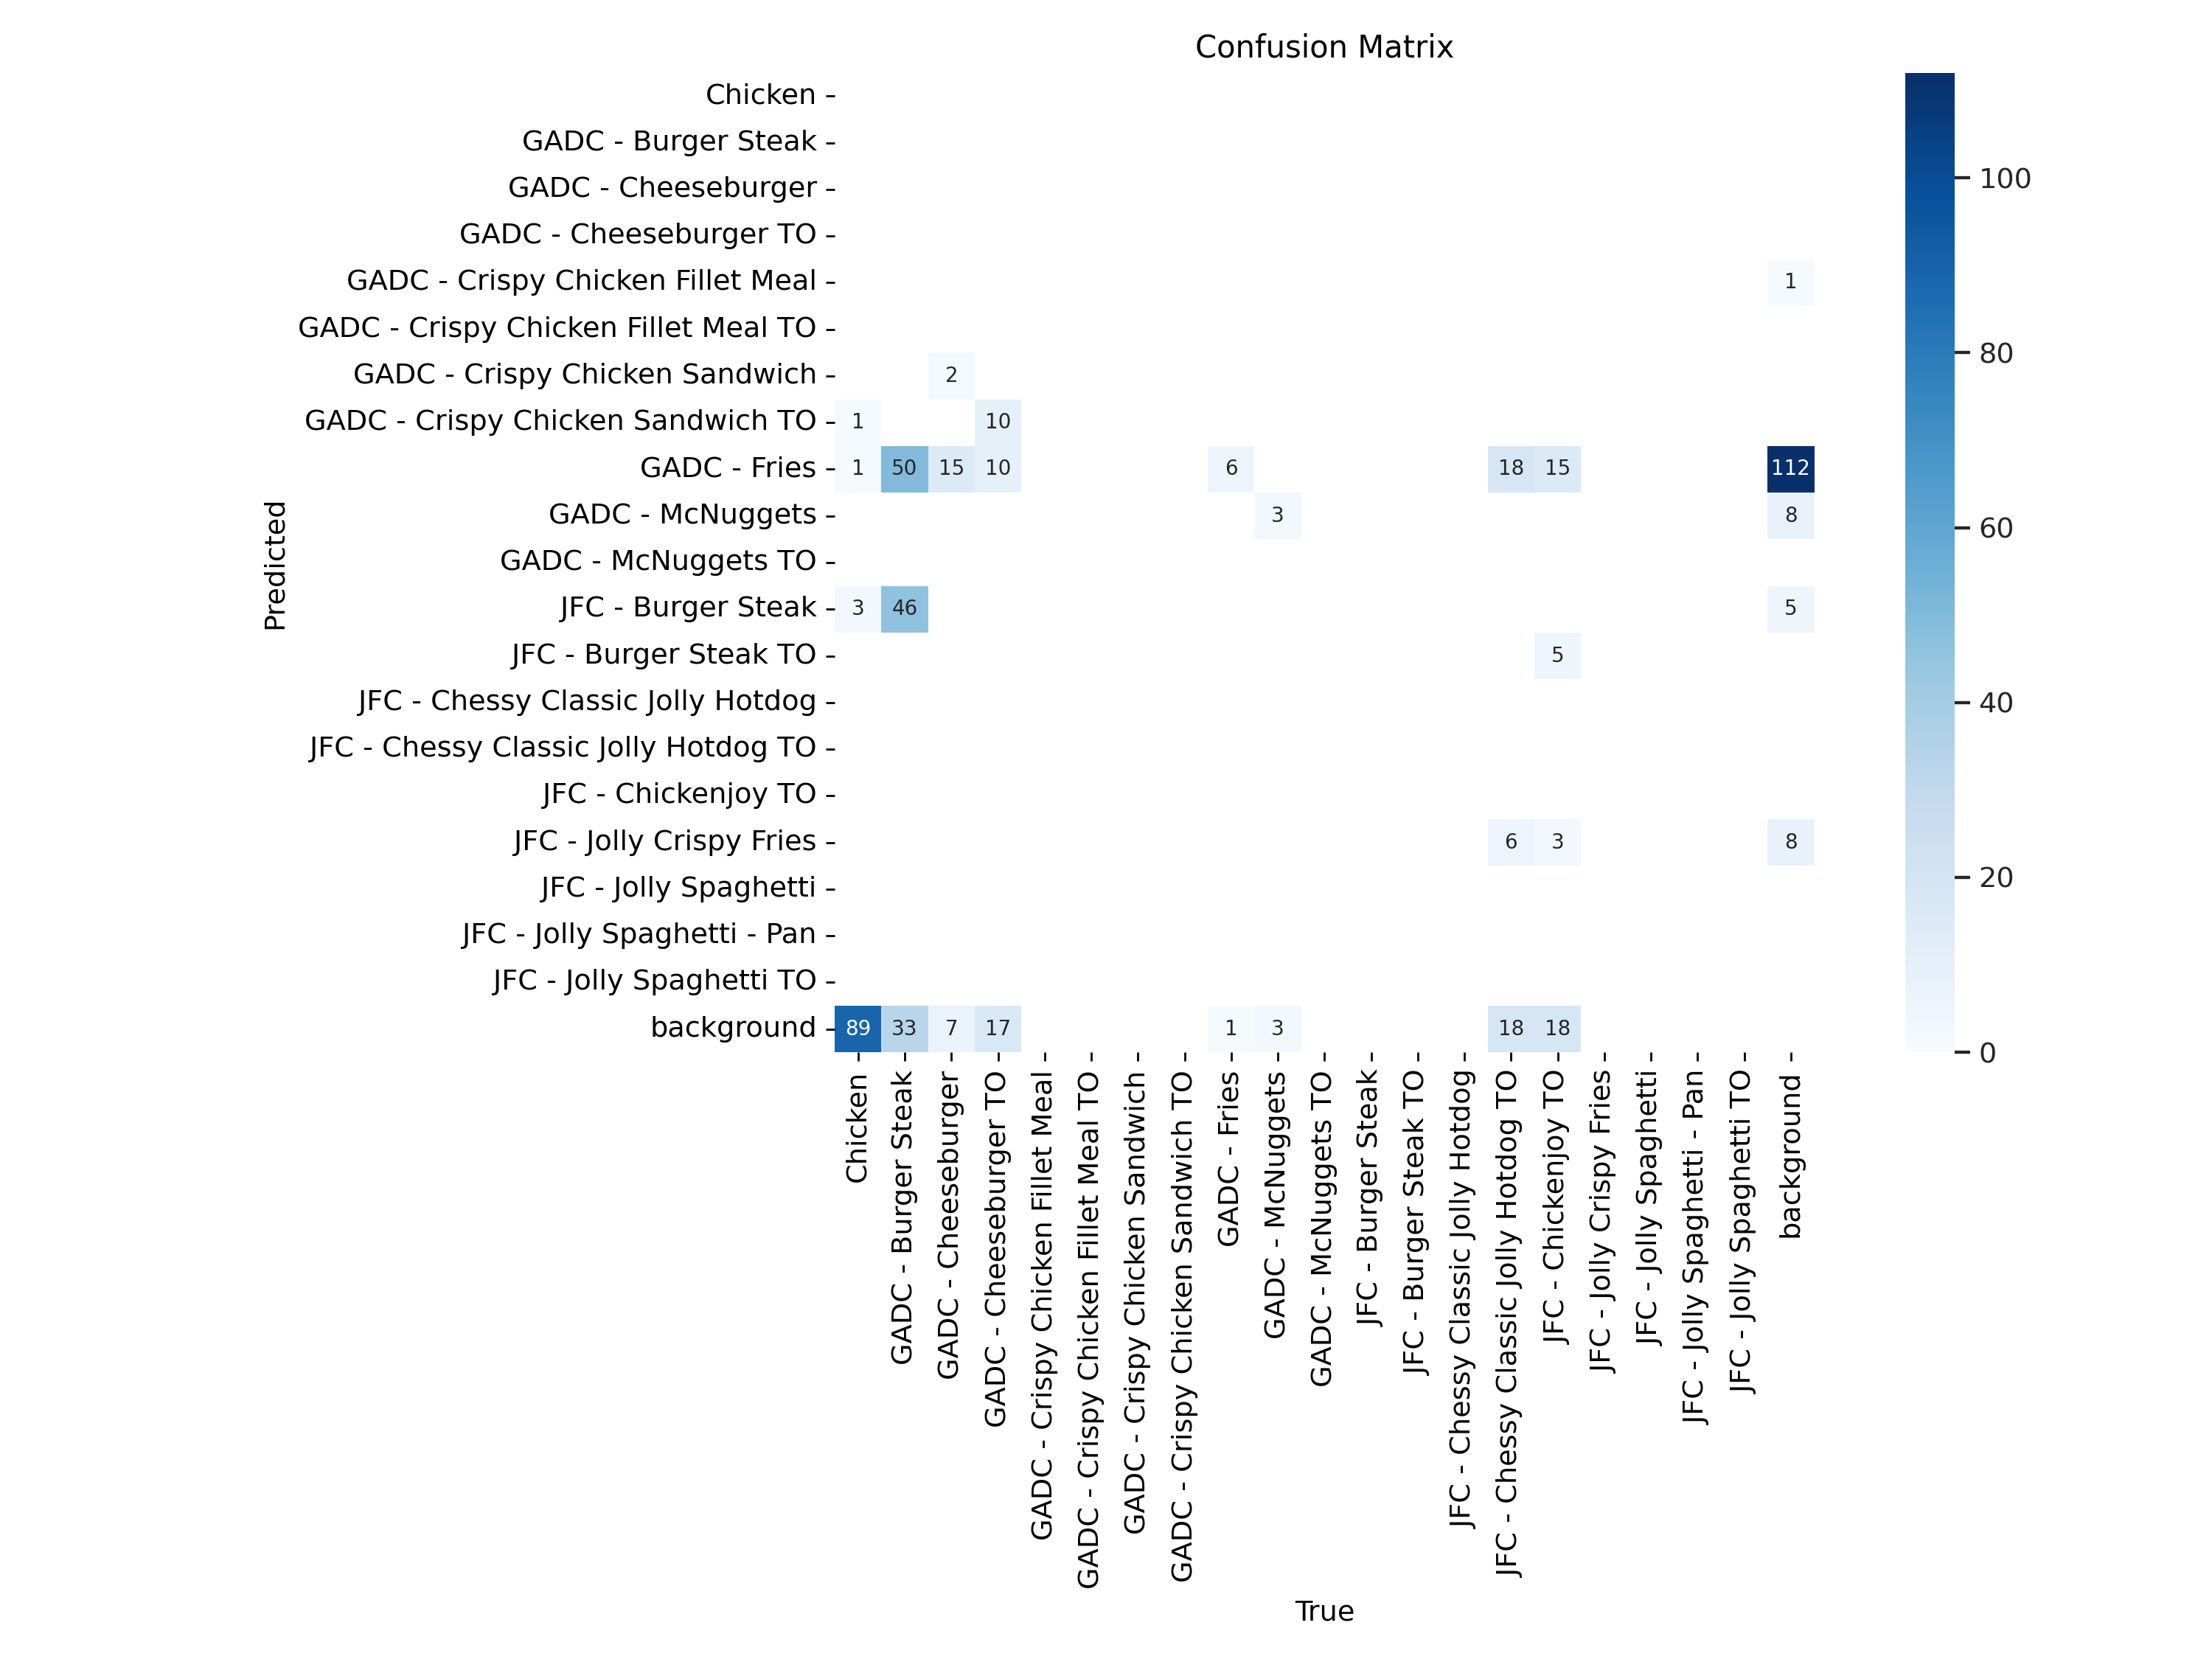

In [21]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

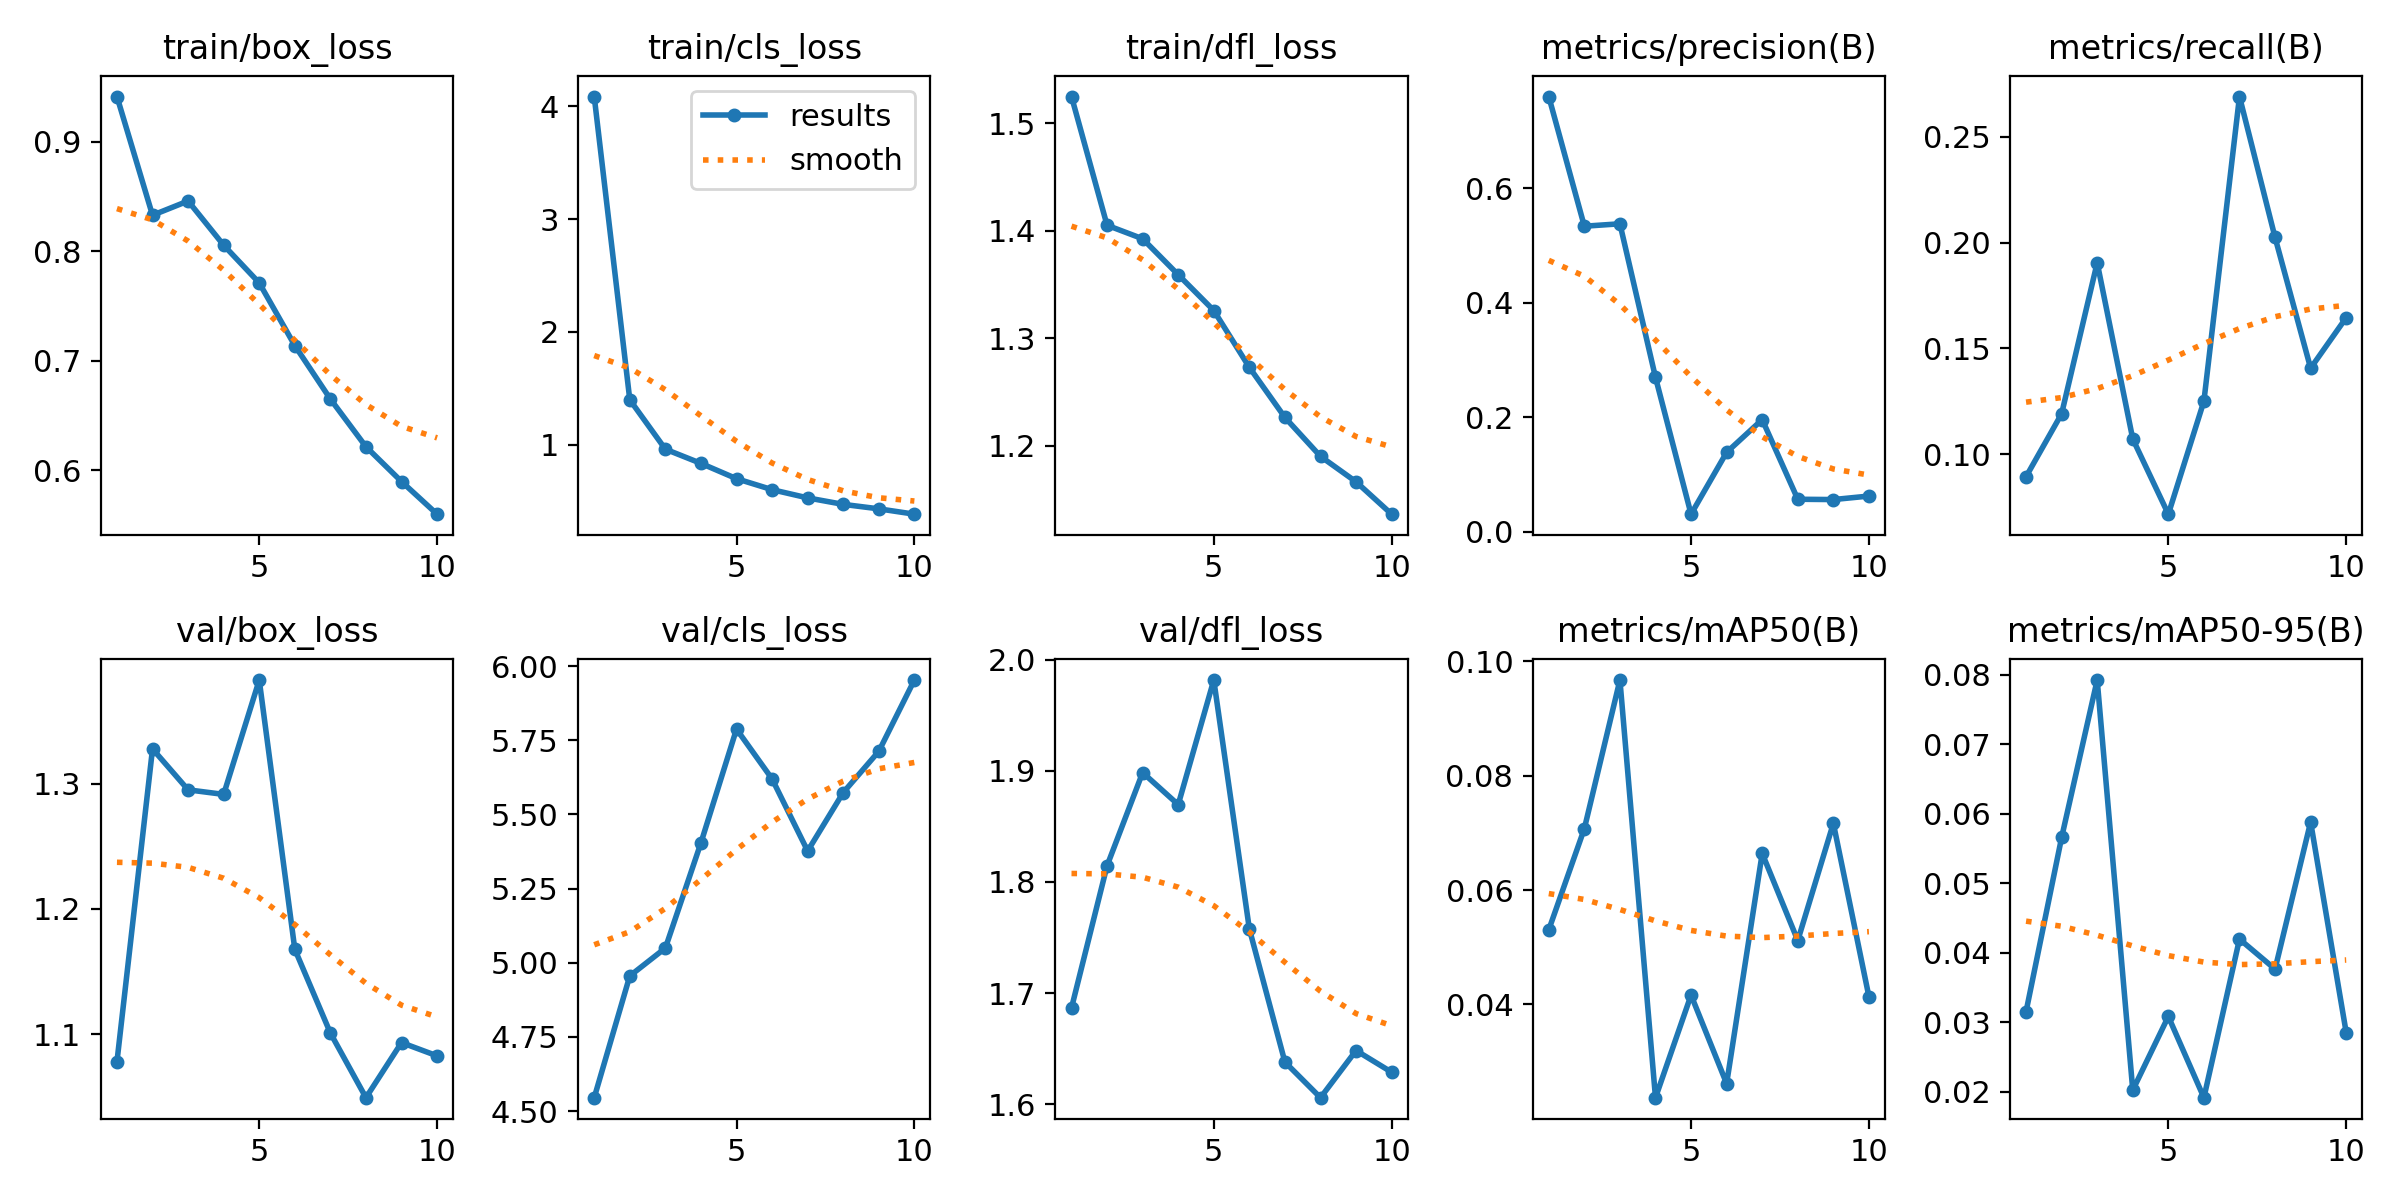

In [22]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=600)

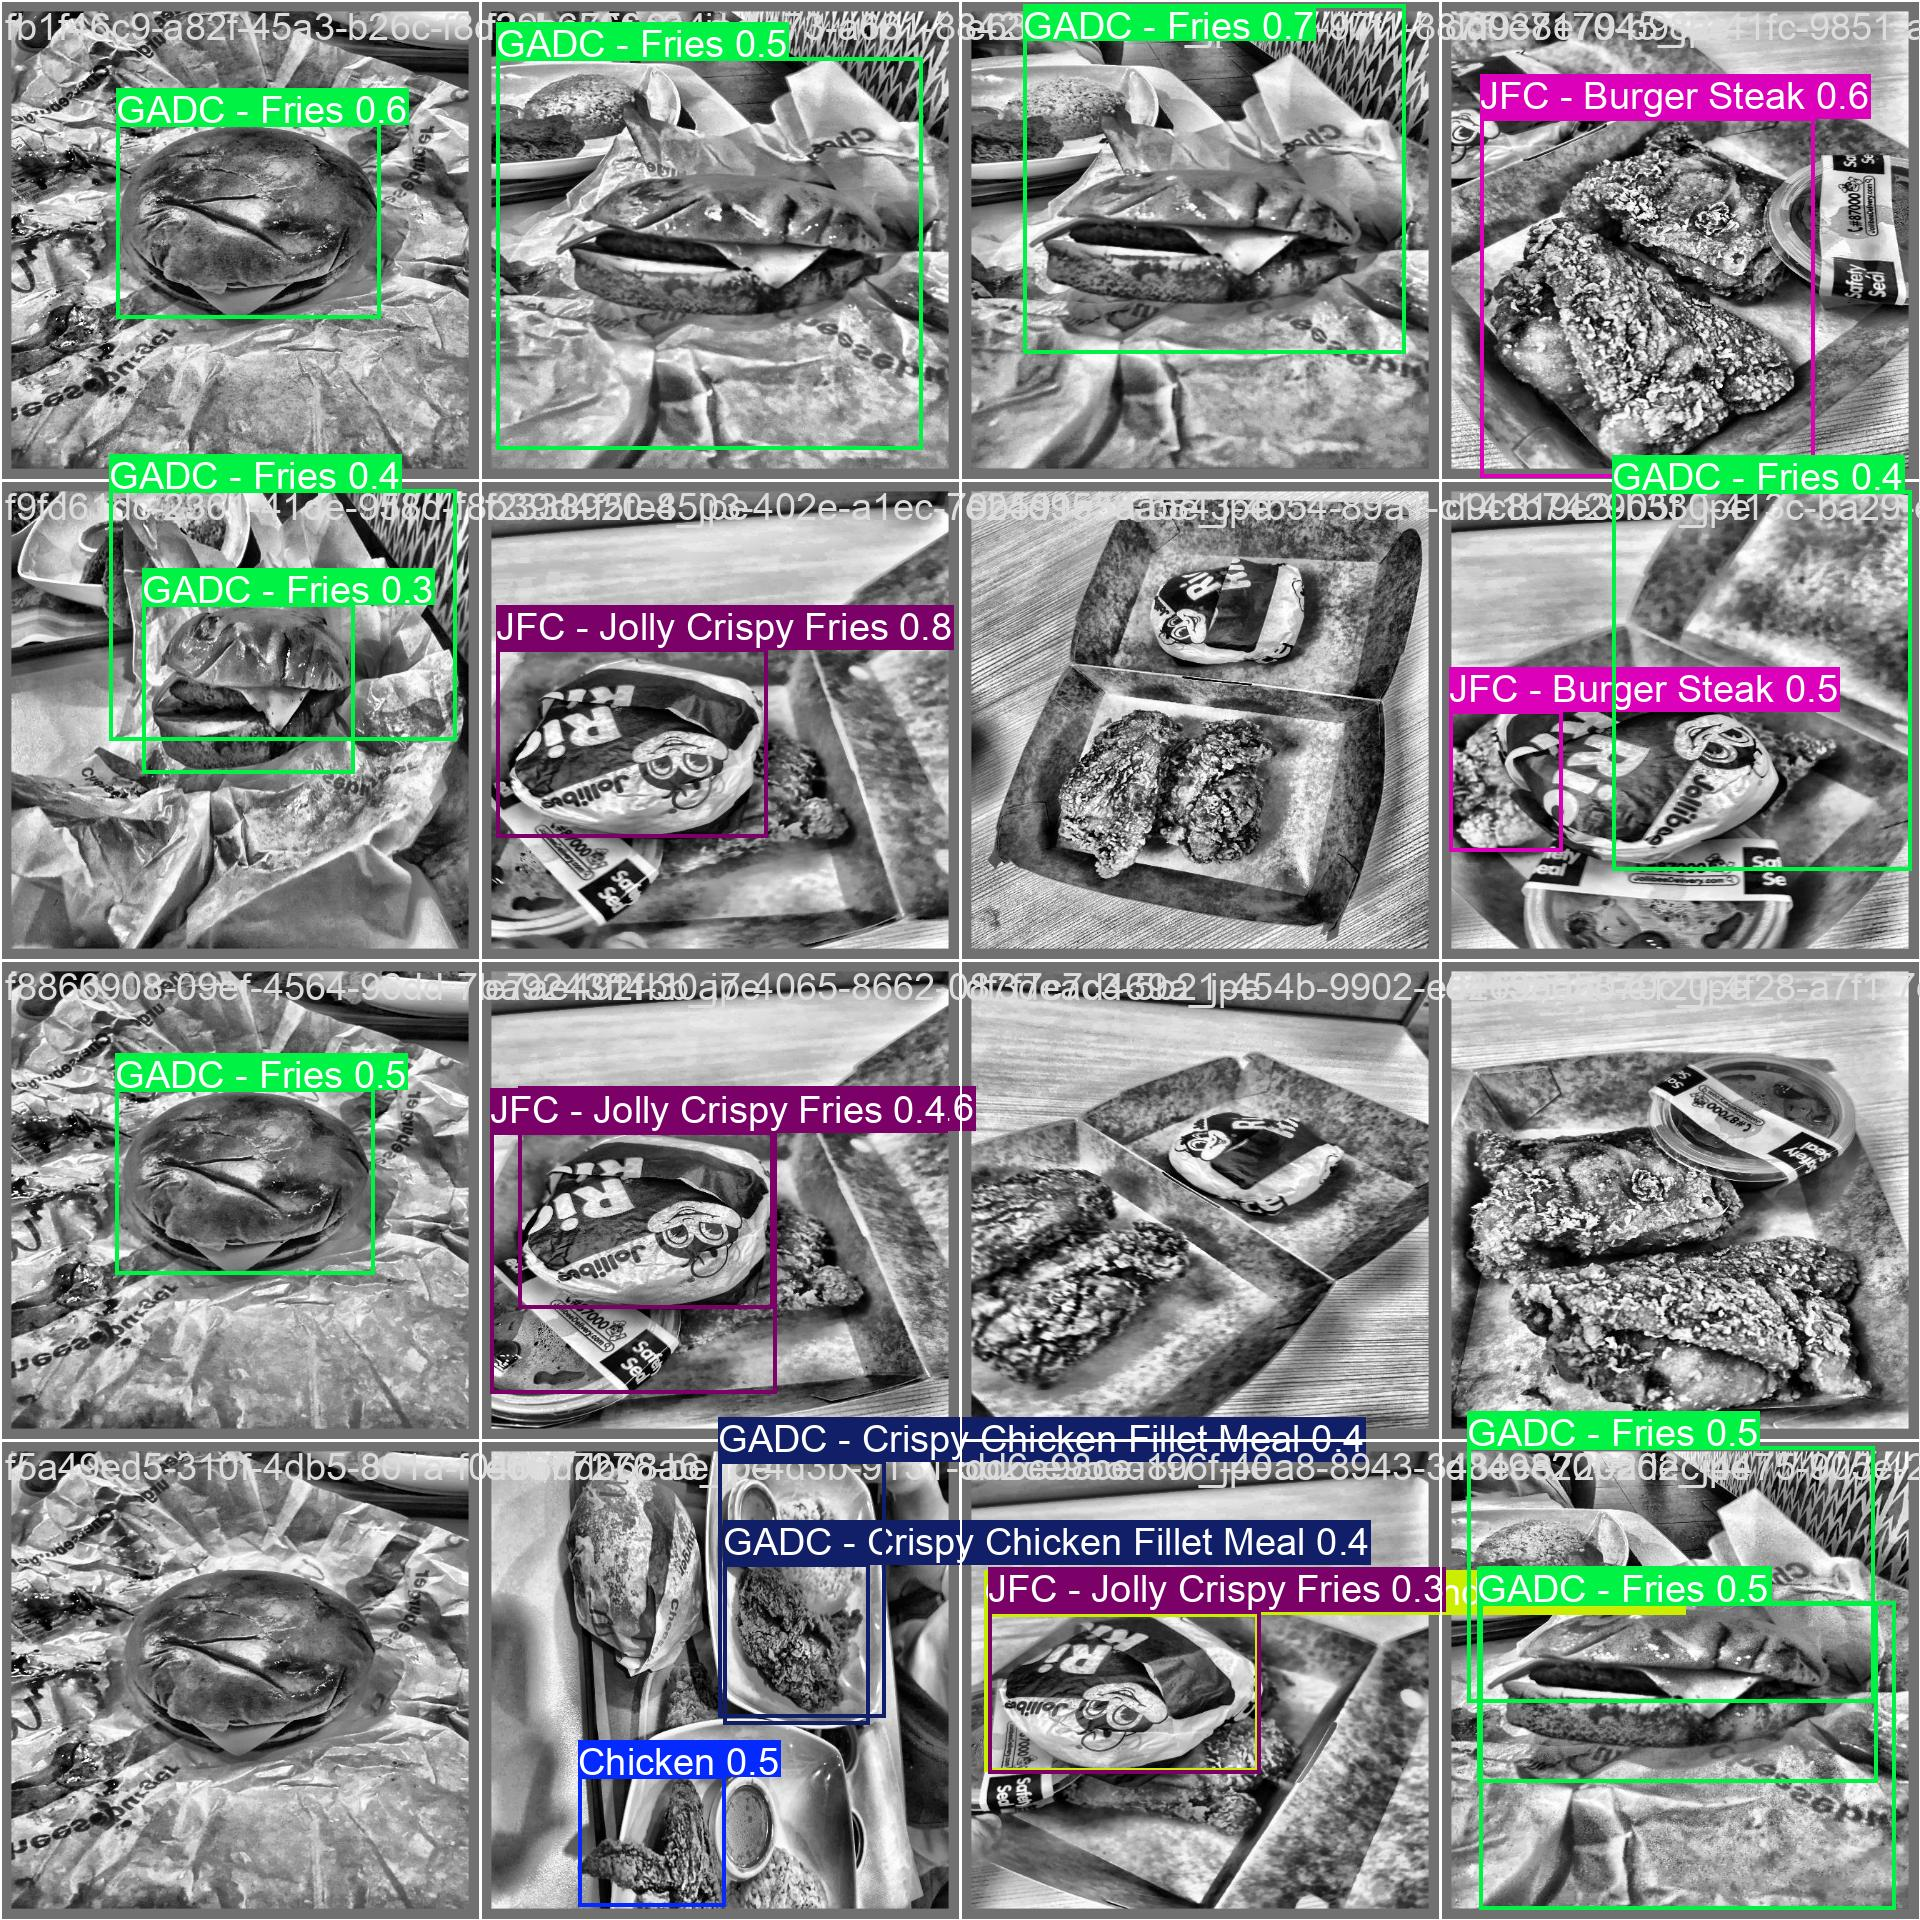

In [23]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

## Validate fine-tuned model

In [ ]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.2 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLO11s summary (fused): 238 layers, 9,421,701 parameters, 0 gradients, 21.3 GFLOPs
val: Scanning /content/datasets/两点钟模型-3/valid/labels.cache... 259 images, 0 backgrounds, 0 corrupt: 100% 259/259 [00:00<?, ?it/s]
val: WARNING ⚠️ /content/datasets/两点钟模型-3/valid/images/08_21C_0250_jpg.rf.b164fca68a7a644a126019aa776912c1.jpg: 2 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 17/17 [00:06<00:00,  2.59it/s]
                   all        259       4652      0.987      0.979      0.991      0.749
                  bag1        258        258      0.986      0.984      0.994       0.78
                  bag2        257        257      0.998          1      0.995      0.892
                  bag3        250        250          1      0.942      0.995      0.808
                  bag4        258        258      0.996          1      0.995      0

## Inference with custom model

In [ ]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

**NOTE:** Let's take a look at few results.

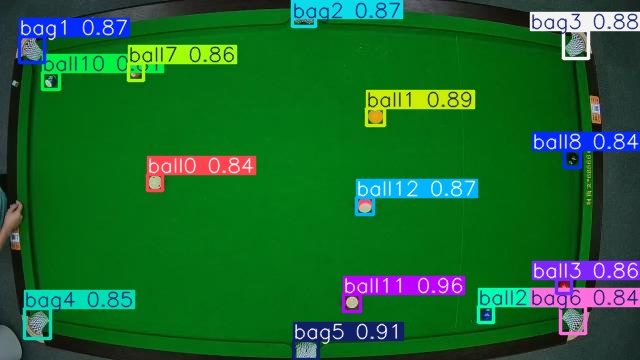

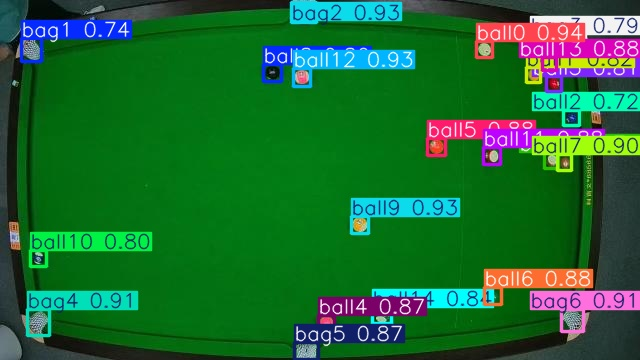

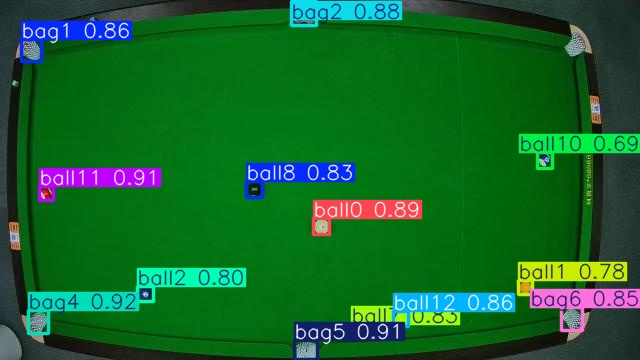

In [ ]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")

## Deploy model on Roboflow

Once you have finished training your YOLOv11 model, you’ll have a set of trained weights ready for use. These weights will be in the `/runs/detect/train/weights/best.pt` folder of your project. You can upload your model weights to Roboflow Deploy to use your trained weights on our infinitely scalable infrastructure.

The `.deploy()` function in the [Roboflow pip package](https://docs.roboflow.com/python) now supports uploading YOLOv11 weights.

In [ ]:
project.version(dataset.version).deploy(model_type="yolov11", model_path=f"{HOME}/runs/detect/train/")

In [ ]:
!pip install inference

In [ ]:
import os, random, cv2
import supervision as sv
import IPython
import inference

model_id = project.id.split("/")[1] + "/" + dataset.version
model = inference.get_model(model_id, userdata.get('ROBOFLOW_API_KEY'))

# Location of test set images
test_set_loc = dataset.location + "/test/images/"
test_images = os.listdir(test_set_loc)

# Run inference on 4 random test images, or fewer if fewer images are available
for img_name in random.sample(test_images, min(4, len(test_images))):
    print("Running inference on " + img_name)

    # Load image
    image = cv2.imread(os.path.join(test_set_loc, img_name))

    # Perform inference
    results = model.infer(image, confidence=0.4, overlap=30)[0]
    detections = sv.Detections.from_inference(results)

    # Annotate boxes and labels
    box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator()
    annotated_image = box_annotator.annotate(scene=image, detections=detections)
    annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

    # Display annotated image
    _, ret = cv2.imencode('.jpg', annotated_image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)


## 🏆 Congratulations

### Learning Resources

Roboflow has produced many resources that you may find interesting as you advance your knowledge of computer vision:

- [Roboflow Notebooks](https://github.com/roboflow/notebooks): A repository of over 20 notebooks that walk through how to train custom models with a range of model types, from YOLOv7 to SegFormer.
- [Roboflow YouTube](https://www.youtube.com/c/Roboflow): Our library of videos featuring deep dives into the latest in computer vision, detailed tutorials that accompany our notebooks, and more.
- [Roboflow Discuss](https://discuss.roboflow.com/): Have a question about how to do something on Roboflow? Ask your question on our discussion forum.
- [Roboflow Models](https://roboflow.com): Learn about state-of-the-art models and their performance. Find links and tutorials to guide your learning.

### Convert data formats

Roboflow provides free utilities to convert data between dozens of popular computer vision formats. Check out [Roboflow Formats](https://roboflow.com/formats) to find tutorials on how to convert data between formats in a few clicks.

### Connect computer vision to your project logic

[Roboflow Templates](https://roboflow.com/templates) is a public gallery of code snippets that you can use to connect computer vision to your project logic. Code snippets range from sending emails after inference to measuring object distance between detections.